# F1 Fantasy 2026 - Prediction Model

## Modelling Formula 1 Outcomes for Fantasy EV Projections (2026 Season)

Adapted from the 2024 model with key updates for the 2026 regulation era:
- **22 drivers / 11 teams** (Cadillac enters as 11th team, Sauber becomes Audi)
- **New power unit regulations**: 50/50 ICE/electric split, MGU-H removed, MGU-K tripled to 350kW
- **Active aerodynamics**: DRS replaced by Boost/Overtake modes
- **Updated Fantasy scoring**: Sprint DNF now -10 (was -20), price floor $3M
- **Regulation-reset uncertainty**: Historical data weighted to account for new era

## 2026 Season Overview

### Key Rule Changes
- Smaller, lighter cars (768kg min, 200mm shorter wheelbase)
- Active aero replaces DRS (Boost button + Overtake Mode)
- 50/50 power split: ~400kW ICE + ~350kW MGU-K
- 100% sustainable fuels
- No fastest lap bonus point in real F1 (abolished 2025), but Fantasy still awards fastest lap points

### 2026 Grid
| Team | Driver 1 | Driver 2 | PU |
|------|----------|----------|-----|
| McLaren | Norris | Piastri | Mercedes |
| Mercedes | Russell | Antonelli | Mercedes |
| Red Bull | Verstappen | Hadjar | Red Bull/Ford |
| Ferrari | Leclerc | Hamilton | Ferrari |
| Williams | Albon | Sainz | Mercedes |
| Racing Bulls | Lawson | Lindblad | Red Bull/Ford |
| Aston Martin | Alonso | Stroll | Honda |
| Haas | Bearman | Ocon | Ferrari |
| Audi | Hulkenberg | Bortoleto | Audi |
| Alpine | Gasly | Colapinto | Mercedes |
| Cadillac | Perez | Bottas | Ferrari |

### Sprint Weekends (6 total)
China, Miami, Canada, Great Britain, Netherlands, Singapore

In [1]:
%pip install -q unidecode gurobipy pulp pandas seaborn scipy scikit-learn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/forest.wang/Dev/f1_fantasy_model/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
from itertools import product

import unidecode
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize
from sklearn.linear_model import LinearRegression
import gurobipy as gp
from pulp import *

import warnings
# Only suppress specific noisy warnings, not all
warnings.filterwarnings('ignore', category=RuntimeWarning, module='scipy')
warnings.filterwarnings('ignore', category=FutureWarning, module='pandas')

In [3]:
# ============================================================
# 2026 Season Constants
# ============================================================
NUM_DRIVERS = 22
NUM_TEAMS = 11
SEASON_YEAR = 2026
TOTAL_RACES = 22

# Fantasy scoring constants
RACE_POINTS = {1: 25, 2: 18, 3: 15, 4: 12, 5: 10, 6: 8, 7: 6, 8: 4, 9: 2, 10: 1}
FINISH_BONUS = 1          # +1 for classified finish
DNF_PENALTY = -20         # Race DNF
SPRINT_DNF_PENALTY = -10  # Sprint DNF (reduced from -20 in 2026)
FASTEST_LAP_PTS = 5       # Fantasy fastest lap points
Q2_BONUS = 2              # Reaching Q2
Q3_BONUS = 3              # Reaching Q3
BEAT_TEAMMATE_RACE = 3
BEAT_TEAMMATE_QUALI = 2
QUAL_STREAK_PTS = 5       # Q3 streak bonus
RACE_STREAK_PTS = 10      # Top-10 streak bonus
POS_GAIN_PTS = 2          # Per position gained (max +10)
NO_CHANCE_ODDS = 501      # Placeholder for "no chance" in odds data

# Sprint race scoring
SPRINT_POINTS = {1: 8, 2: 7, 3: 6, 4: 5, 5: 4, 6: 3, 7: 2, 8: 1}
NUM_SPRINTS = 6

# Budget
FANTASY_BUDGET = 100      # $100M budget cap

# 2026 driver/team mapping
TEAMS_2026 = {
    'McLaren': ['Norris', 'Piastri'],
    'Mercedes': ['Russell', 'Antonelli'],
    'Red Bull': ['Verstappen', 'Hadjar'],
    'Ferrari': ['Leclerc', 'Hamilton'],
    'Williams': ['Albon', 'Sainz'],
    'Racing Bulls': ['Lawson', 'Lindblad'],
    'Aston Martin': ['Alonso', 'Stroll'],
    'Haas': ['Bearman', 'Ocon'],
    'Audi': ['Hulkenberg', 'Bortoleto'],
    'Alpine': ['Gasly', 'Colapinto'],
    'Cadillac': ['Perez', 'Bottas'],
}

# Reverse mapping: driver -> team
DRIVER_TEAM = {}
for team, drivers in TEAMS_2026.items():
    for d in drivers:
        DRIVER_TEAM[d] = team

ALL_DRIVERS = list(DRIVER_TEAM.keys())
ALL_TEAMS = list(TEAMS_2026.keys())

# ============================================================
# 2026 Race Calendar (slug for Oddschecker URLs)
# ============================================================
RACE_CALENDAR = [
    {'round': 1,  'name': 'Australian Grand Prix',    'slug': 'australian-grand-prix',    'date': '2026-03-08', 'sprint': False},
    {'round': 2,  'name': 'Chinese Grand Prix',       'slug': 'chinese-grand-prix',       'date': '2026-03-15', 'sprint': True},
    {'round': 3,  'name': 'Japanese Grand Prix',      'slug': 'japanese-grand-prix',      'date': '2026-03-29', 'sprint': False},
    {'round': 4,  'name': 'Miami Grand Prix',         'slug': 'miami-grand-prix',         'date': '2026-05-03', 'sprint': True},
    {'round': 5,  'name': 'Emilia Romagna Grand Prix','slug': 'emilia-romagna-grand-prix','date': '2026-05-17', 'sprint': False},
    {'round': 6,  'name': 'Monaco Grand Prix',        'slug': 'monaco-grand-prix',        'date': '2026-05-31', 'sprint': False},
    {'round': 7,  'name': 'Spanish Grand Prix',       'slug': 'spanish-grand-prix',       'date': '2026-06-14', 'sprint': False},
    {'round': 8,  'name': 'Canadian Grand Prix',      'slug': 'canadian-grand-prix',      'date': '2026-06-28', 'sprint': True},
    {'round': 9,  'name': 'Austrian Grand Prix',      'slug': 'austrian-grand-prix',      'date': '2026-07-12', 'sprint': False},
    {'round': 10, 'name': 'British Grand Prix',       'slug': 'british-grand-prix',       'date': '2026-07-19', 'sprint': True},
    {'round': 11, 'name': 'Belgian Grand Prix',       'slug': 'belgian-grand-prix',       'date': '2026-08-02', 'sprint': False},
    {'round': 12, 'name': 'Hungarian Grand Prix',     'slug': 'hungarian-grand-prix',     'date': '2026-08-16', 'sprint': False},
    {'round': 13, 'name': 'Dutch Grand Prix',         'slug': 'dutch-grand-prix',         'date': '2026-08-30', 'sprint': True},
    {'round': 14, 'name': 'Italian Grand Prix',       'slug': 'italian-grand-prix',       'date': '2026-09-06', 'sprint': False},
    {'round': 15, 'name': 'Azerbaijan Grand Prix',    'slug': 'azerbaijan-grand-prix',    'date': '2026-09-20', 'sprint': False},
    {'round': 16, 'name': 'Singapore Grand Prix',     'slug': 'singapore-grand-prix',     'date': '2026-10-04', 'sprint': True},
    {'round': 17, 'name': 'United States Grand Prix', 'slug': 'united-states-grand-prix', 'date': '2026-10-18', 'sprint': False},
    {'round': 18, 'name': 'Mexican Grand Prix',       'slug': 'mexican-grand-prix',       'date': '2026-10-25', 'sprint': False},
    {'round': 19, 'name': 'Brazilian Grand Prix',     'slug': 'brazilian-grand-prix',     'date': '2026-11-08', 'sprint': False},
    {'round': 20, 'name': 'Las Vegas Grand Prix',     'slug': 'las-vegas-grand-prix',     'date': '2026-11-22', 'sprint': False},
    {'round': 21, 'name': 'Qatar Grand Prix',         'slug': 'qatar-grand-prix',         'date': '2026-11-29', 'sprint': False},
    {'round': 22, 'name': 'Abu Dhabi Grand Prix',     'slug': 'abu-dhabi-grand-prix',     'date': '2026-12-06', 'sprint': False},
]

# Auto-detect current race from date
from datetime import date
_today = date.today()
CURRENT_RACE = next((r for r in RACE_CALENDAR if date.fromisoformat(r['date']) >= _today), RACE_CALENDAR[-1])
RACE_SLUG = CURRENT_RACE['slug']
IS_SPRINT_WEEKEND = CURRENT_RACE['sprint']
RACES_COMPLETED = CURRENT_RACE['round'] - 1

print(f"Grid: {len(ALL_DRIVERS)} drivers across {len(ALL_TEAMS)} teams")
print(f"Next race: Round {CURRENT_RACE['round']} - {CURRENT_RACE['name']} ({CURRENT_RACE['date']})")
print(f"Sprint weekend: {IS_SPRINT_WEEKEND}")
print(f"Races completed: {RACES_COMPLETED}")

# ============================================================
# UPDATE EACH RACE WEEK: Current team & streaks
# ============================================================
# Your current Fantasy team (empty = fresh start / season opener)
MY_DRIVERS = []           # e.g. ['Leclerc', 'Lawson', 'Colapinto', 'Perez', 'Bottas']
MY_CONSTRUCTORS = []      # e.g. ['Mercedes', 'Ferrari']
AVAILABLE_TRANSFERS = 12  # Free transfers available (12 = fresh start)

# Drivers/teams currently on streaks (empty at season start)
q_streak_drivers = ['Antonelli', 'Russell', 'Leclerc', 'Hamilton', 'Piastri', 'Norris', 'Gasly', 'Hadjar']  # Q3 in both R2 & R3
race_streak_drivers = ['Antonelli', 'Russell', 'Leclerc', 'Hamilton', 'Gasly', 'Lawson']  # Top-10 in both R2 & R3
q_streak_teams = ['Mercedes', 'Ferrari', 'McLaren', 'Red Bull', 'Alpine']  # At least one driver Q3 in both R2 & R3
race_streak_teams = ['Mercedes', 'Ferrari', 'Alpine', 'Racing Bulls']  # At least one driver top-10 in both R2 & R3


Grid: 22 drivers across 11 teams
Next race: Round 3 - Japanese Grand Prix (2026-03-29)
Sprint weekend: False
Races completed: 2


## Part 1: Converting Odds into Implied Probabilities

The first step is to collect betting odds for each driver across 6 markets:
- `winner`: Win probability
- `top3`: Podium probability
- `top6`: Top-6 finish
- `top10`: Points finish
- `flap`: Fastest lap
- `dnf`: Did not finish

We use the shortest decimal odds available (highest implied probability) from spread betting and traditional bookmakers.

### Automated Odds Scraping

Scrape latest bookmaker odds from Oddschecker using Playwright. Fetches 5 markets (winner, podium/top3, top6, points/top10, fastest lap) and selects the best (shortest) decimal odds across all available bookmakers.

DNF odds are estimated from historical retirement rates by team reliability tier since Oddschecker doesn't offer a DNF market.

**Update `RACE_SLUG` below before each race** (e.g. `australian-grand-prix`, `chinese-grand-prix`).

Falls back to the existing `odds_2026.csv` if Playwright is unavailable or scraping fails.

In [4]:
# ============================================================
# Oddschecker Odds Scraper (uses RACE_SLUG from config cell)
# ============================================================
ODDSCHECKER_BASE = f'https://www.oddschecker.com/motorsport/formula-1/{RACE_SLUG}'

# Oddschecker market slugs -> our column names
MARKETS = {
    'winner': 'winner',
    'podium-finish': 'top3',
    'top-6-finish': 'top6',
    'points-finish': 'top10',
    'fastest-lap': 'flap',
}

# DNF estimates by team reliability tier (no Oddschecker market for DNF)
DNF_ESTIMATES = {
    'Mercedes': 8.0, 'Red Bull': 8.0, 'Ferrari': 8.0, 'McLaren': 7.0,
    'Alpine': 9.0, 'Williams': 8.0, 'Aston Martin': 10.0,
    'Haas': 9.0, 'Audi': 10.0, 'Racing Bulls': 9.0, 'Cadillac': 12.0,
}

# Driver name mapping: Oddschecker display name -> model name
DRIVER_NAME_MAP = {
    'Max Verstappen': 'Verstappen', 'George Russell': 'Russell',
    'Lando Norris': 'Norris', 'Charles Leclerc': 'Leclerc',
    'Oscar Piastri': 'Piastri', 'Lewis Hamilton': 'Hamilton',
    'Andrea Kimi Antonelli': 'Antonelli', 'Kimi Antonelli': 'Antonelli',
    'Isack Hadjar': 'Hadjar', 'Pierre Gasly': 'Gasly',
    'Carlos Sainz': 'Sainz', 'Alex Albon': 'Albon',
    'Alexander Albon': 'Albon',
    'Fernando Alonso': 'Alonso', 'Lance Stroll': 'Stroll',
    'Oliver Bearman': 'Bearman', 'Esteban Ocon': 'Ocon',
    'Nico Hulkenberg': 'Hulkenberg', 'Liam Lawson': 'Lawson',
    'Gabriel Bortoleto': 'Bortoleto', 'Franco Colapinto': 'Colapinto',
    'Arvid Lindblad': 'Lindblad', 'Sergio Perez': 'Perez',
    'Valtteri Bottas': 'Bottas', 'Yuki Tsunoda': 'Tsunoda',
    'Kevin Magnussen': 'Magnussen', 'Daniel Ricciardo': 'Ricciardo',
    'Jack Doohan': 'Doohan', 'Logan Sargeant': 'Sargeant',
    'Nyck De Vries': 'De Vries', 'Zhou Guanyu': 'Zhou',
}

async def scrape_single_market(market_slug, col_name):
    """Scrape a single Oddschecker market using its own browser instance."""
    from playwright.async_api import async_playwright
    market_odds = {}
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True, args=[
            '--disable-blink-features=AutomationControlled',
        ])
        ctx = await browser.new_context(
            user_agent='Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
                       'AppleWebKit/537.36 (KHTML, like Gecko) '
                       'Chrome/131.0.0.0 Safari/537.36',
            viewport={'width': 1920, 'height': 1080},
        )
        page = await ctx.new_page()
        await page.add_init_script(
            "Object.defineProperty(navigator, 'webdriver', {get: () => undefined})"
        )

        url = f'{ODDSCHECKER_BASE}/{market_slug}'
        print(f'  [{col_name}] Scraping {market_slug}...')
        try:
            await page.goto(url, timeout=30000)
            await page.wait_for_timeout(3000)
            await page.wait_for_selector('tr.diff-row', timeout=20000)
            rows = await page.query_selector_all('tr.diff-row')

            for row in rows:
                name_el = await row.query_selector('td.sel.nm span.pointed-at-for-mobile')
                if not name_el:
                    name_el = await row.query_selector('td.sel.nm a.selTxt')
                if not name_el:
                    continue
                raw_name = (await name_el.inner_text()).strip()
                driver = DRIVER_NAME_MAP.get(raw_name, raw_name.split()[-1] if raw_name else None)
                if not driver or driver not in ALL_DRIVERS:
                    continue

                odds_cells = await row.query_selector_all('td.bc.bs:not(.oi)')
                valid_odds = []
                for cell in odds_cells:
                    try:
                        odig = await cell.get_attribute('data-odig')
                        if odig:
                            dec = float(odig)
                        else:
                            text = (await cell.inner_text()).strip()
                            if not text or text == '-':
                                continue
                            if '/' in text:
                                num, den = text.split('/')
                                dec = float(num) / float(den) + 1
                            else:
                                dec = float(text) + 1
                        if dec > 1.01:
                            valid_odds.append(dec)
                    except (ValueError, ZeroDivisionError, TypeError):
                        continue

                if valid_odds:
                    valid_odds.sort()
                    median = valid_odds[len(valid_odds) // 2]
                    filtered = [o for o in valid_odds if o >= median * 0.2]
                    best = min(filtered) if filtered else min(valid_odds)
                else:
                    best = float('inf')

                if best < float('inf') and best > 1.02:
                    market_odds[driver] = round(best, 2)

            print(f'  [{col_name}] Got {len(market_odds)} drivers')
        except Exception as e:
            print(f'  [{col_name}] Failed: {e}')

        await browser.close()
    return col_name, market_odds


async def scrape_oddschecker_odds():
    """Scrape odds from Oddschecker for all F1 markets using parallel browsers."""
    try:
        from playwright.async_api import async_playwright
    except ImportError:
        print('Playwright not installed - using CSV fallback')
        return None

    tasks = [scrape_single_market(slug, col) for slug, col in MARKETS.items()]
    results = await asyncio.gather(*tasks)

    all_odds = {}
    for col_name, market_odds in results:
        for driver, odds_val in market_odds.items():
            if driver not in all_odds:
                all_odds[driver] = {}
            all_odds[driver][col_name] = odds_val

    if not all_odds:
        print('No odds scraped - using CSV fallback')
        return None

    rows = []
    for driver in ALL_DRIVERS:
        if driver not in all_odds:
            print(f'  WARNING: No odds for {driver}, skipping')
            continue
        odds = all_odds[driver]
        team = DRIVER_TEAM[driver]
        dnf = DNF_ESTIMATES.get(team, 10)
        w = odds.get('winner', NO_CHANCE_ODDS)
        t3 = odds.get('top3', max(w * 0.25, 1.5))
        t6 = odds.get('top6', max(w * 0.08, 1.2))
        t10 = odds.get('top10', max(w * 0.03, 1.05))
        fl = odds.get('flap', max(t3 * 2.0, 3.0))  # fallback: flap correlates with podium pace more than winning
        rows.append({
            'driver': driver, 'team': team,
            'winner': w, 'top3': t3, 'top6': t6, 'top10': t10, 'flap': fl, 'dnf': dnf,
        })

    result = pd.DataFrame(rows)
    for col_high, col_low in [('winner','top3'), ('top3','top6'), ('top6','top10')]:
        mask = result[col_high] < result[col_low]
        if mask.any():
            result.loc[mask, col_low] = result.loc[mask, col_high]
    return result

# --- Scrape or fallback ---
import asyncio
from datetime import datetime
print(f'Fetching odds from Oddschecker ({RACE_SLUG})...')
scraped_odds = await scrape_oddschecker_odds()

if scraped_odds is not None and len(scraped_odds) >= 20:
    print(f'\nSUCCESS: Scraped odds for {len(scraped_odds)} drivers')
    scraped_odds.to_csv('odds_2026.csv', index=False)
    print(f'Updated odds_2026.csv at {datetime.now().strftime("%Y-%m-%d %H:%M")}')
else:
    print('\nUsing existing odds_2026.csv (scrape returned insufficient data)')

print('\nOdds preview:')
pd.read_csv('odds_2026.csv').head(10)

Scraper skipped (--skip-scraper)


In [5]:
# Load odds data - update odds_2026.csv before each race with latest bookmaker odds
# Format: driver,team,winner,top3,top6,top10,flap,dnf
df = pd.read_csv('odds_2026.csv', index_col=0)
for _col in ['winner', 'top3', 'top6', 'top10', 'flap', 'dnf']:
    df[_col] = df[_col].astype(float)

# Verify all 2026 drivers are present
missing = [d for d in ALL_DRIVERS if d not in df.index]
if missing:
    print(f"WARNING: Missing drivers in odds_2026.csv: {missing}")

df

,team,winner,top3,top6,top10,flap,dnf
driver,,,,,,,
Norris,McLaren,21.00,5.50,1.57,1.13,11.30,7.0
Piastri,McLaren,21.00,5.50,1.57,1.14,11.30,7.0
Russell,Mercedes,1.53,1.08,1.05,1.03,2.67,8.0
Antonelli,Mercedes,3.40,1.13,1.06,1.03,2.80,8.0
Verstappen,Red Bull,19.00,5.50,1.33,1.08,11.00,8.0
Hadjar,Red Bull,67.00,21.00,2.40,1.29,31.00,8.0
Leclerc,Ferrari,9.00,1.71,1.10,1.04,4.92,8.0
Hamilton,Ferrari,7.50,1.71,1.10,1.04,4.92,8.0
Albon,Williams,251.00,101.00,26.00,6.00,151.00,8.0


Convert decimal odds to implied probabilities (multiplicative inverse), then correct for bookmaker overround using the power method.

In [6]:
odds_cols = ['winner', 'top3', 'top6', 'top10', 'flap', 'dnf']
for col in odds_cols:
    df[col] **= -1
df

,team,winner,top3,top6,top10,flap,dnf
driver,,,,,,,
Norris,McLaren,0.047619,0.181818,0.636943,0.884956,0.088496,0.142857
Piastri,McLaren,0.047619,0.181818,0.636943,0.877193,0.088496,0.142857
Russell,Mercedes,0.653595,0.925926,0.952381,0.970874,0.374532,0.125000
Antonelli,Mercedes,0.294118,0.884956,0.943396,0.970874,0.357143,0.125000
Verstappen,Red Bull,0.052632,0.181818,0.751880,0.925926,0.090909,0.125000
Hadjar,Red Bull,0.014925,0.047619,0.416667,0.775194,0.032258,0.125000
Leclerc,Ferrari,0.111111,0.584795,0.909091,0.961538,0.203252,0.125000
Hamilton,Ferrari,0.133333,0.584795,0.909091,0.961538,0.203252,0.125000
Albon,Williams,0.003984,0.009901,0.038462,0.166667,0.006623,0.125000


In [7]:
def adjust_odds(odds_series, target_sum, method='power'):
    """Remove bookmaker overround using power or linear normalization."""
    if method == 'power':
        def f(x):
            return sum([i**x for i in odds_series]) - target_sum
        k, info, ier, msg = optimize.fsolve(f, 1, full_output=True)[:4]
        if ier != 1:
            print(f"  WARNING: fsolve did not converge for overround adjustment: {msg}")
            return odds_series / sum(odds_series) * target_sum  # fallback to linear
        result = odds_series ** k
        if (result < 0).any() or (result > 1).any():
            print(f"  WARNING: adjusted probabilities out of [0,1], falling back to linear")
            return odds_series / sum(odds_series) * target_sum
        return result
    elif method == 'linear':
        return odds_series / sum(odds_series) * target_sum

In [8]:
# Winner sums to 1, top3 to 3, top6 to 6, top10 to 10, flap to 1
for col, target in zip(odds_cols[:-1], [1, 3, 6, 10, 1]):
    df[col] = adjust_odds(df[col], target)

# Enforce bracket monotonicity: winner <= top3 <= top6 <= top10
# Power method overround correction adjusts each column independently,
# which can break the cumulative ordering for midfield/backmarker drivers.
for driver in df.index:
    df.loc[driver, 'top3'] = max(df.loc[driver, 'top3'], df.loc[driver, 'winner'])
    df.loc[driver, 'top6'] = max(df.loc[driver, 'top6'], df.loc[driver, 'top3'])
    df.loc[driver, 'top10'] = max(df.loc[driver, 'top10'], df.loc[driver, 'top6'])
df

,team,winner,top3,top6,top10,flap,dnf
driver,,,,,,,
Norris,McLaren,0.019911,0.089982,0.500947,0.830194,0.044322,0.142857
Piastri,McLaren,0.019911,0.089982,0.500947,0.819131,0.044322,0.142857
Russell,Mercedes,0.578645,0.896985,0.927958,0.955990,0.283050,0.125000
Antonelli,Mercedes,0.207159,0.841436,0.914576,0.955990,0.266274,0.125000
Verstappen,Red Bull,0.022647,0.089982,0.645955,0.889421,0.045882,0.125000
Hadjar,Red Bull,0.004476,0.013559,0.261422,0.678594,0.012116,0.125000
Leclerc,Ferrari,0.059219,0.468671,0.864107,0.942029,0.129036,0.125000
Hamilton,Ferrari,0.074872,0.468671,0.864107,0.942029,0.129036,0.125000
Albon,Williams,0.000819,0.001475,0.006786,0.065335,0.001584,0.125000


Adjust DNF probabilities so that a driver's DNF + top10 probability cannot exceed 1. We use a log-ratio power transform anchored to the constraint that top drivers have ~96% chance of top-10 if they finish.

In [9]:
# Adjust DNF probabilities so top10 + dnf < 1 for all drivers
# Use 0.96 anchor but cap at drivers' actual top10 probability
anchor = np.minimum(0.96, 1 - df['dnf'] - 0.01)  # ensure feasibility
valid = (anchor - df['top10']) > 0  # only adjust where formula is valid
if valid.all():
    df['dnf'] **= (np.log(anchor - df['top10']) / np.log(df['dnf'])).max()
else:
    # Fallback: scale DNF so top10 + dnf <= 0.98 for all drivers
    max_dnf = np.minimum(df['dnf'], 1 - df['top10'] - 0.02)
    df['dnf'] = np.maximum(max_dnf, 0.005)  # floor at 0.5%

# Safety clamp: ensure 1 - top10 - dnf > 0 for QP feasibility
df['dnf'] = np.minimum(df['dnf'], 1 - df['top10'] - 0.01)
df['dnf'] = np.maximum(df['dnf'], 0.005)

df['winner'] = df[['winner', 'top3']].min(axis=1)
df

,team,winner,top3,top6,top10,flap,dnf
driver,,,,,,,
Norris,McLaren,0.019911,0.089982,0.500947,0.830194,0.044322,0.142857
Piastri,McLaren,0.019911,0.089982,0.500947,0.819131,0.044322,0.142857
Russell,Mercedes,0.578645,0.896985,0.927958,0.955990,0.283050,0.024010
Antonelli,Mercedes,0.207159,0.841436,0.914576,0.955990,0.266274,0.024010
Verstappen,Red Bull,0.022647,0.089982,0.645955,0.889421,0.045882,0.090579
Hadjar,Red Bull,0.004476,0.013559,0.261422,0.678594,0.012116,0.125000
Leclerc,Ferrari,0.059219,0.468671,0.864107,0.942029,0.129036,0.037971
Hamilton,Ferrari,0.074872,0.468671,0.864107,0.942029,0.129036,0.037971
Albon,Williams,0.000819,0.001475,0.006786,0.065335,0.001584,0.125000


## Part 2: Estimating Race Finishing Position Distributions

For each driver, we solve a quadratic programming problem (Gurobi) to find the smoothest probability distribution over finishing positions P1-P22, anchored to the odds-implied probabilities for each bracket.

**2026 change**: 22 positions instead of 20 (Cadillac adds 2 drivers).

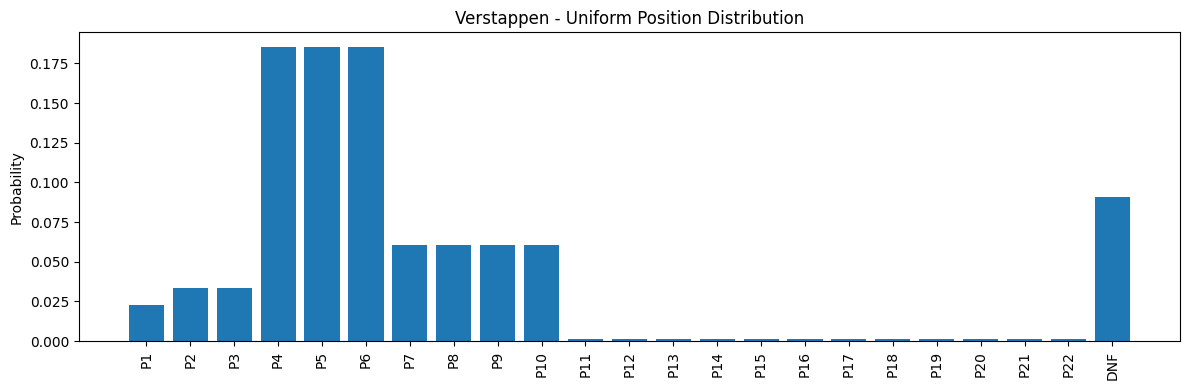

In [10]:
def get_probs(idx):
    """Get uniform distribution within each odds bracket for a driver."""
    probs = [df.loc[idx, 'winner']]
    probs += [(df.loc[idx, 'top3'] - df.loc[idx, 'winner']) / 2] * 2
    probs += [(df.loc[idx, 'top6'] - df.loc[idx, 'top3']) / 3] * 3
    probs += [(df.loc[idx, 'top10'] - df.loc[idx, 'top6']) / 4] * 4
    # 12 non-points positions for 22-driver grid (P11-P22)
    probs += [(1 - df.loc[idx, 'top10'] - df.loc[idx, 'dnf']) / 12] * 12
    probs.append(df.loc[idx, 'dnf'])
    return probs

driver = 'Verstappen'
plt.figure(figsize=(12, 4))
plt.bar(['P{}'.format(i) for i in range(1, NUM_DRIVERS + 1)] + ['DNF'], get_probs(driver))
plt.xticks(rotation=90)
plt.ylabel('Probability')
plt.title(f'{driver} - Uniform Position Distribution')
plt.tight_layout()
plt.show()

Restricted license - for non-production use only - expires 2027-11-29


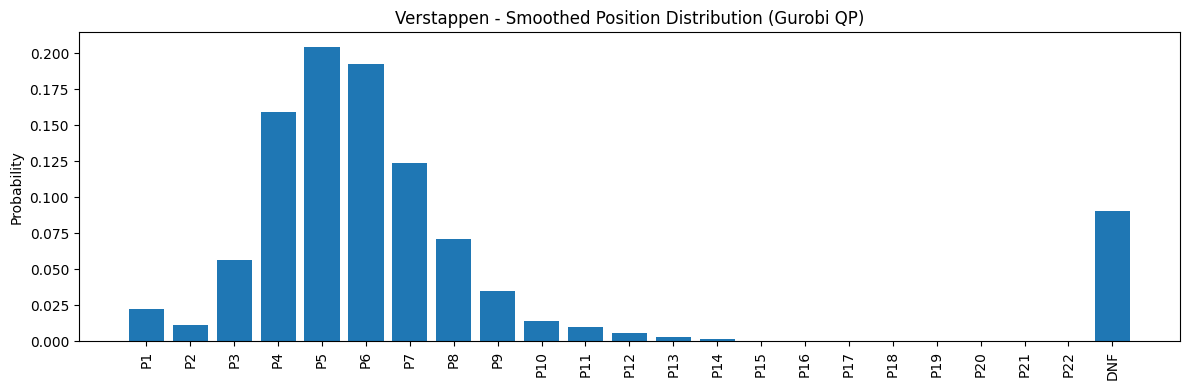

In [11]:
def smooth_position_distribution(driver, df, num_drivers=NUM_DRIVERS):
    """Solve QP to get smooth position probability distribution from odds brackets."""
    quadratic_model = gp.Model('quadratic')
    quadratic_model.setParam('outputFlag', False)

    x = {i: quadratic_model.addVar(vtype=gp.GRB.CONTINUOUS, lb=0, ub=1, name=f'x_{i}')
         for i in range(1, num_drivers + 1)}

    obj = sum([(x[i] - x[i + 1])**2 for i in range(1, num_drivers)])
    quadratic_model.setObjective(obj, gp.GRB.MINIMIZE)

    quadratic_model.addConstr(x[1] == df.loc[driver, 'winner'])
    quadratic_model.addConstr(x[2] + x[3] == df.loc[driver, 'top3'] - df.loc[driver, 'winner'])
    quadratic_model.addConstr(x[4] + x[5] + x[6] == df.loc[driver, 'top6'] - df.loc[driver, 'top3'])
    quadratic_model.addConstr(x[7] + x[8] + x[9] + x[10] == df.loc[driver, 'top10'] - df.loc[driver, 'top6'])
    quadratic_model.addConstr(sum([x[i] for i in range(11, num_drivers + 1)]) == 1 - df.loc[driver, 'top10'] - df.loc[driver, 'dnf'])
    if df.loc[driver, 'top10'] >= 0.5:
        quadratic_model.addConstr(x[num_drivers] == 0)

    quadratic_model.optimize()
    return {i + 1: v.x for i, v in enumerate(quadratic_model.getVars())}

# Demonstrate smooth distribution for one driver
driver = 'Verstappen'
demo_dist = smooth_position_distribution(driver, df)
vals = list(demo_dist.values())

plt.figure(figsize=(12, 4))
plt.bar(['P{}'.format(i) for i in range(1, NUM_DRIVERS + 1)] + ['DNF'], vals + [df.loc[driver, 'dnf']])
plt.xticks(rotation=90)
plt.ylabel('Probability')
plt.title(f'{driver} - Smoothed Position Distribution (Gurobi QP)')
plt.tight_layout()
plt.show()

In [12]:
# Compute smoothed position distributions for all drivers
pos_dict = {}

for driver in df.index:
    pos_dict[driver] = smooth_position_distribution(driver, df)

print(f"Position distributions computed for {len(pos_dict)} drivers")

Position distributions computed for 22 drivers


In [13]:
pos_df = pd.DataFrame(pos_dict).T
pos_df['dnf'] = df.dnf
pos_df['team'] = df.team
pos_df['mean_pos'] = sum([i / (1 - df['dnf']) * pos_df[i] for i in range(1, NUM_DRIVERS + 1)])
pos_df.head(10).T

,Norris,Piastri,Russell,Antonelli,Verstappen,Hadjar,Leclerc,Hamilton,Albon,Sainz
1,0.019911,0.019911,0.578645,0.207159,0.022647,0.004476,0.059219,0.074872,0.000819,0.000819
2,0.019319,0.019201,0.251164,0.339475,0.010953,0.0,0.185283,0.18064,0.000394,0.000669
3,0.050753,0.05087,0.067176,0.294802,0.056382,0.009082,0.224169,0.213159,0.000262,0.000527
4,0.114212,0.114919,0.026682,0.07314,0.158934,0.054648,0.175878,0.17243,0.000425,0.000393
5,0.147159,0.147483,0.00429,0.0,0.204365,0.087019,0.130756,0.131784,0.001474,0.001914
6,0.149594,0.148563,0.0,0.0,0.192674,0.106196,0.088802,0.091222,0.003412,0.005092
7,0.121516,0.118157,0.004323,0.006608,0.123862,0.112179,0.050017,0.050743,0.00624,0.009929
8,0.094604,0.090551,0.007126,0.010749,0.071139,0.111417,0.022288,0.022047,0.01073,0.015575
9,0.068855,0.065743,0.00841,0.012424,0.034505,0.103912,0.005616,0.005132,0.016882,0.022029
10,0.044272,0.043734,0.008174,0.011632,0.013959,0.089664,0.0,0.0,0.024696,0.029293


## Part 3: Race EV, Fastest Lap, and DNF Penalty

Compute expected fantasy points from race finishing position, fastest lap probability, and DNF penalty.

In [14]:
ev_df = pd.DataFrame(index=df.index)

# Race position points: P1=25, P2=18, ..., P10=1, plus +1 finish bonus
ev_df['race'] = (25 * pos_df[1] + 18 * pos_df[2] + 15 * pos_df[3]
                 + 12 * pos_df[4] + 10 * pos_df[5] + 8 * pos_df[6]
                 + 6 * pos_df[7] + 4 * pos_df[8] + 2 * pos_df[9]
                 + pos_df[10] + (1 - pos_df['dnf']) * FINISH_BONUS)

# Fastest lap (5 fantasy points)
ev_df['flap'] = df['flap'] * FASTEST_LAP_PTS

# DNF penalty (-20 points)
ev_df['dnf'] = DNF_PENALTY * df['dnf']

ev_df.sort_values('race', ascending=False).head(10)

,race,flap,dnf
driver,,,
Russell,21.413235,1.415250,-0.480201
Antonelli,17.684348,1.331369,-0.480201
Hamilton,13.802411,0.645181,-0.759428
Leclerc,13.669126,0.645181,-0.759428
Verstappen,9.121432,0.229409,-1.811590
Norris,7.792325,0.221611,-2.857143
Piastri,7.752317,0.221611,-2.857143
Hadjar,4.914912,0.060579,-2.500000
Bearman,3.743275,0.031949,-2.222222


## Part 3b: Sprint Race EV

For sprint weekends (6 in 2026), we model additional points from sprint races.
Sprint scoring: P1=8, P2=7, ..., P8=1. Sprint DNF penalty is -10 (reduced from -20 in 2026).

Since sprint results correlate with race pace, we approximate sprint EV from the position distributions.

In [15]:
# Sprint EV per weekend (approximate from position distribution)
# SPRINT_POINTS and NUM_SPRINTS defined in config cell
sprint_ev = sum([SPRINT_POINTS.get(i, 0) * pos_df[i] for i in range(1, NUM_DRIVERS + 1)])
sprint_ev += SPRINT_DNF_PENALTY * pos_df['dnf']

# Amortize sprint EV across the season (or use full sprint EV if this is a sprint weekend)
if IS_SPRINT_WEEKEND:
    ev_df.loc[:, 'sprint'] = sprint_ev
    print(f"Sprint weekend: using full sprint EV")
else:
    ev_df.loc[:, 'sprint'] = sprint_ev * NUM_SPRINTS / TOTAL_RACES
    print(f"Non-sprint weekend: amortized sprint EV ({NUM_SPRINTS}/{TOTAL_RACES})")

ev_df.loc[:, 'sprint']

Non-sprint weekend: amortized sprint EV (6/22)


driver
Norris        0.304521
Piastri       0.302025
Russell       1.831803
Antonelli     1.623265
Verstappen    0.599826
Hadjar        0.031632
Leclerc       1.234684
Hamilton      1.240685
Albon        -0.326633
Sainz        -0.320530
Lawson       -0.183792
Lindblad     -0.225769
Alonso       -0.268402
Stroll       -0.269324
Bearman      -0.064165
Ocon         -0.193243
Hulkenberg   -0.233620
Bortoleto    -0.234282
Gasly        -0.064800
Colapinto    -0.254389
Perez        -0.224287
Bottas       -0.224287
Name: sprint, dtype: float64

## Part 4: Modelling Points from Non-Odds Sources

We use historical F1 data (2021-2025) to build regression models predicting:
1. **Qualifying EV** from mean race position (polynomial)
2. **Q2 appearance probability** (logistic regression)
3. **Q3 appearance probability** (logistic regression)
4. **Position gains EV** (linear regression)

**2026 Regulation Reset Note**: The 2022-2025 ground-effect era data is most relevant.
We use all available data but the relationships between grid/race position and fantasy points
should remain stable across regulation changes.

In [16]:
race_hist_df = pd.read_csv("f1db_csv/races.csv")
hist_result_df = pd.read_csv("f1db_csv/results.csv")

# Use 2021-2025 data (or whatever is available)
max_year = race_hist_df['year'].max()
hist_years = list(range(2021, max_year + 1))
print(f"Using historical data from {hist_years[0]} to {hist_years[-1]}")

Using historical data from 2021 to 2026


In [17]:
# Gather IDs of all races per year
race_dict = {}
for year in hist_years:
    races = race_hist_df[race_hist_df['year'] == year]['raceId'].tolist()
    race_dict[year] = races

# Collect per-driver season stats
values = {'grid': [], 'position': [], 'fantasy': [], 'top10': [], 'top15': [], 'mean_gain': []}

for year in race_dict:
    season_df = hist_result_df[hist_result_df['raceId'].isin(race_dict[year])]
    drivers = season_df['driverId'].unique()
    for driver in drivers:
        driver_season = season_df[season_df['driverId'] == driver]
        grid_pos_df = driver_season[['grid', 'position']][
            driver_season['position'].str.isnumeric() & (driver_season['grid'] != 0)
        ].copy()
        grid_pos_df['grid'] = grid_pos_df['grid'].astype(float)
        grid_pos_df['position'] = grid_pos_df['position'].astype(float)

        if len(grid_pos_df) > 15:
            values['grid'].append(grid_pos_df['grid'].mean())
            values['position'].append(grid_pos_df['position'].mean())
            values['fantasy'].append(
                sum([sum(grid_pos_df['grid'] == i) * (11 - i) for i in range(1, 11)]) / len(grid_pos_df)
            )
            values['top10'].append(sum(grid_pos_df['grid'] <= 10) / len(grid_pos_df))
            values['top15'].append(sum(grid_pos_df['grid'] <= 15) / len(grid_pos_df))

            total = 0
            for idx in grid_pos_df.index:
                g = grid_pos_df.loc[idx, 'grid']
                p = grid_pos_df.loc[idx, 'position']
                if g - p > 0:
                    total += min(10, (g - p) * POS_GAIN_PTS)
                elif g - p < 0:
                    if g <= 10:
                        total += max(-10, (g - p) * POS_GAIN_PTS)
                    else:
                        total += max(-5, g - p)
            values['mean_gain'].append(total / len(grid_pos_df))

hist_stats_df = pd.DataFrame(values)
print(f"Collected {len(hist_stats_df)} driver-seasons for regression")
hist_stats_df.head()

Collected 95 driver-seasons for regression


,grid,position,fantasy,top10,top15,mean_gain
0,3.047619,2.761905,7.952381,0.952381,1.000000,0.857143
1,3.052632,1.842105,8.421053,0.947368,0.947368,1.157895
2,5.777778,5.000000,6.055556,0.833333,0.888889,0.666667
3,6.904762,6.619048,4.714286,0.857143,0.952381,0.380952
4,5.500000,5.250000,5.500000,0.937500,1.000000,1.500000


### Qualifying EV from Mean Race Position

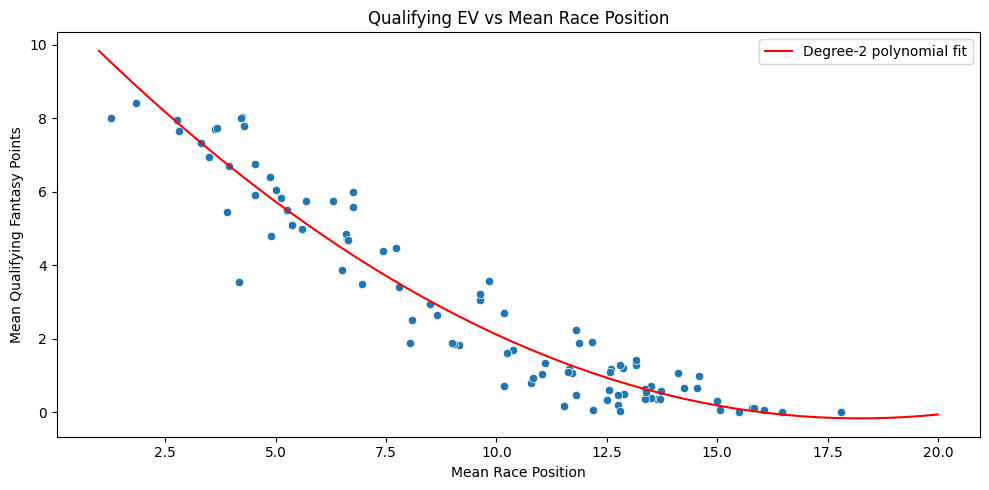

In [18]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='position', y='fantasy', data=hist_stats_df)
weights = np.polyfit(hist_stats_df['position'], hist_stats_df['fantasy'], 2)
model_qual = np.poly1d(weights)
x_line = np.linspace(1, 20)
plt.plot(x_line, model_qual(x_line), 'r-', label='Degree-2 polynomial fit')
plt.xlabel('Mean Race Position')
plt.ylabel('Mean Qualifying Fantasy Points')
plt.title('Qualifying EV vs Mean Race Position')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Fit polynomial once, reuse in function (avoid refitting on every call)
_qual_weights = np.polyfit(hist_stats_df['position'], hist_stats_df['fantasy'], 2)
_qual_model = np.poly1d(_qual_weights)

def qual_pts(pos):
    return max(_qual_model(pos), 0)

### Q2 Appearance Probability (Logistic Regression)

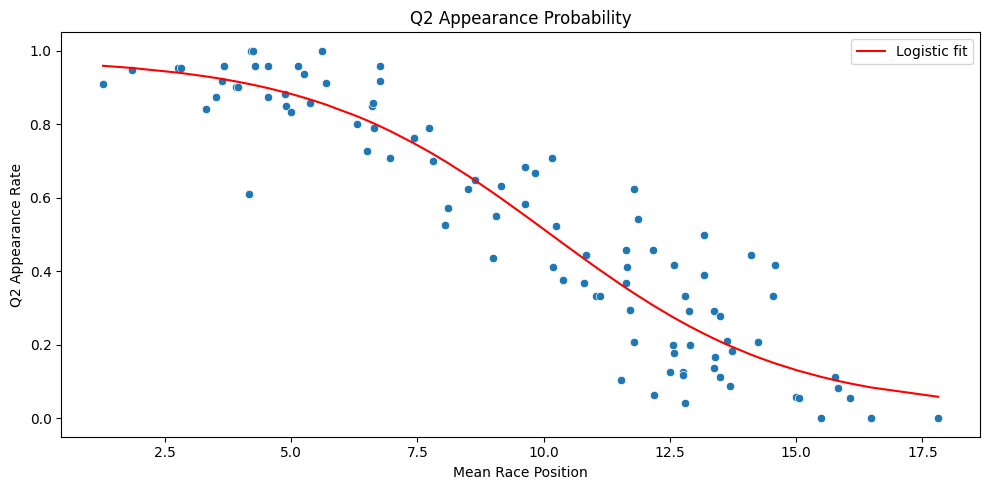

In [20]:
hist_stats_df = hist_stats_df.sort_values(by='position')

plt.figure(figsize=(10, 5))
sns.scatterplot(x=hist_stats_df['position'], y=hist_stats_df['top10'])

x_data = hist_stats_df['position'].to_numpy()
y_data = hist_stats_df['top10'].to_numpy()

def logistic_f(x, a, b, c, d):
    return a / (1. + np.exp(-c * (x - d))) + b

popt, pcov = optimize.curve_fit(logistic_f, x_data, y_data, method="trf")
y_fit = logistic_f(x_data, *popt)
plt.plot(x_data, y_fit, 'r-', label='Logistic fit')
plt.xlabel('Mean Race Position')
plt.ylabel('Q2 Appearance Rate')
plt.title('Q2 Appearance Probability')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# Logistic model for qualifying stage probability
def _logistic(x, a, b, c, d):
    return a / (1. + np.exp(-c * (x - d))) + b

# Fit curves once, reuse in functions (avoid refitting ~44+ times)
_x_hist = hist_stats_df['position'].to_numpy()
_q2_popt, _ = optimize.curve_fit(_logistic, _x_hist, hist_stats_df['top10'].to_numpy(), method="trf")
_q3_popt, _ = optimize.curve_fit(_logistic, _x_hist, hist_stats_df['top15'].to_numpy(), method="trf")

def q2_finish_pts(pos):
    return max(_logistic(pos, *_q2_popt) * Q2_BONUS, 0)

def q3_finish_pts(pos):
    return max(_logistic(pos, *_q3_popt) * Q3_BONUS, 0)

### Q3 Appearance Probability

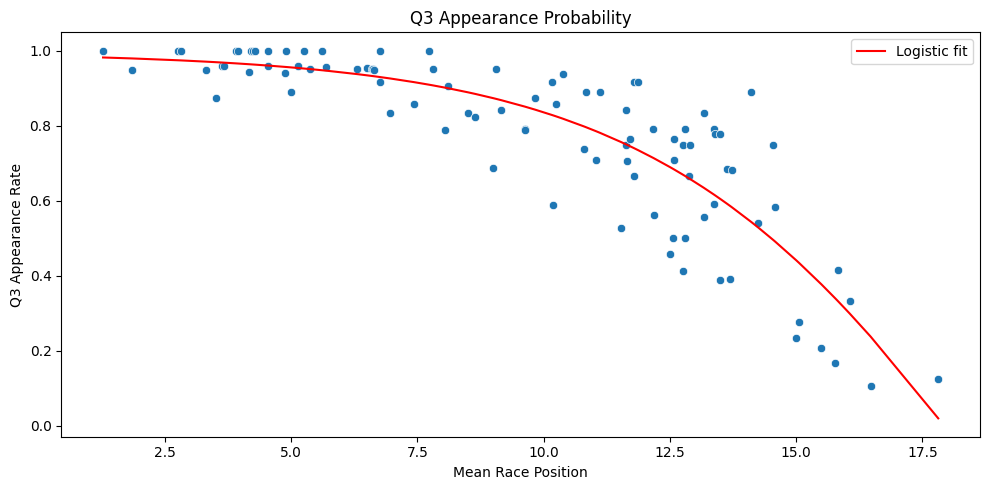

In [22]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=hist_stats_df['position'], y=hist_stats_df['top15'])

x_data = hist_stats_df['position'].to_numpy()
y_data = hist_stats_df['top15'].to_numpy()

popt, pcov = optimize.curve_fit(logistic_f, x_data, y_data, method="trf")
y_fit = logistic_f(x_data, *popt)
plt.plot(x_data, y_fit, 'r-', label='Logistic fit')
plt.xlabel('Mean Race Position')
plt.ylabel('Q3 Appearance Rate')
plt.title('Q3 Appearance Probability')
plt.legend()
plt.tight_layout()
plt.show()

### Position Gains EV

<Figure size 1000x500 with 0 Axes>

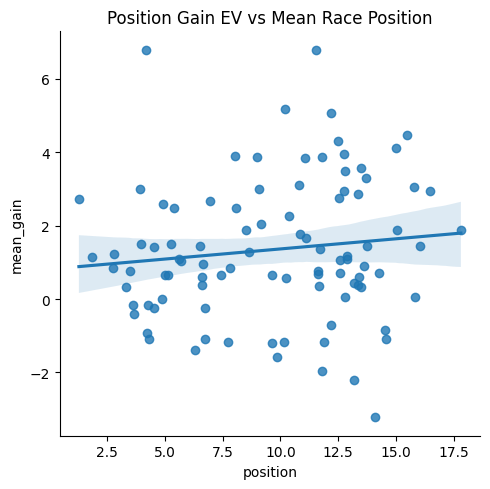

In [23]:
plt.figure(figsize=(10, 5))
sns.lmplot(x='position', y='mean_gain', data=hist_stats_df)
plt.title('Position Gain EV vs Mean Race Position')
plt.tight_layout()
plt.show()

In [24]:
# Fit regression once, reuse in function (avoid refitting on every call)
_gain_reg = LinearRegression().fit(
    hist_stats_df['position'].values.reshape(-1, 1),
    hist_stats_df['mean_gain'].values.reshape(-1, 1)
)

def gain_pts(pos):
    return _gain_reg.predict(np.array([[pos]]))[0][0]

### Apply Regression Models to 2026 Drivers

In [25]:
ev_df['qual'] = [qual_pts(i) for i in pos_df['mean_pos']]
ev_df['gain'] = [gain_pts(i) for i in pos_df['mean_pos']]
ev_df['q'] = [q2_finish_pts(i) + q3_finish_pts(i) for i in pos_df['mean_pos']]

ev_df.sort_values('qual', ascending=False).head(10)

,race,flap,dnf,sprint,qual,gain,q
driver,,,,,,,
Russell,21.413235,1.415250,-0.480201,1.831803,8.762525,0.920301,4.840356
Antonelli,17.684348,1.331369,-0.480201,1.623265,7.931597,0.963098,4.805640
Hamilton,13.802411,0.645181,-0.759428,1.240685,6.637597,1.034385,4.722538
Leclerc,13.669126,0.645181,-0.759428,1.234684,6.615705,1.035646,4.720714
Verstappen,9.121432,0.229409,-1.811590,0.599826,5.156311,1.124930,4.550553
Norris,7.792325,0.221611,-2.857143,0.304521,4.750103,1.151907,4.480167
Piastri,7.752317,0.221611,-2.857143,0.302025,4.711432,1.154532,4.472773
Hadjar,4.914912,0.060579,-2.500000,0.031632,3.153492,1.270670,4.038177
Bearman,3.743275,0.031949,-2.222222,-0.064165,2.493138,1.328134,3.743921


## Part 5: Teammate Comparisons

We scrape current-season results to estimate the probability of each driver beating their teammate.
Probabilities are Bayesian-shrunk toward 0.5 to account for small sample sizes.

Since the 2026 season hasn't started yet (or has just begun), we use pre-season estimates
based on relative expected positions from odds, or early-season data as available.

In [26]:
# 2026 race URLs - update this list as races complete
# Format: "raceId/circuit-name"
hrefs = [
    "1279/australia",  # Round 1 - Melbourne
    "1280/china",      # Round 2 - Shanghai
    "1281/japan",      # Round 3 - Suzuka
]

# https://www.formula1.com/en/results.html/2026/races/XXXX/australia/qualifying.html
qualifying_dfs, race_dfs, grid_dfs = [], [], []
season_length = 3  # Update after each race

def parse_f1_driver_name(raw):
    """Parse F1.com driver name format: 'George\xa0RussellRUS' -> 'Russell'"""
    import re
    clean = re.sub(r'[A-Z]{3}$', '', raw).replace('\xa0', ' ').strip()
    return unidecode.unidecode(clean.split()[-1])

# Column renames for backward compatibility with downstream cells
_col_rename = {'Pos.': 'Pos', 'Team': 'Car'}

for href in hrefs[:season_length]:
    qualifying_url = f'https://www.formula1.com/en/results.html/2026/races/{href}/qualifying.html'
    qual_result = pd.read_html(qualifying_url)[0].rename(columns=_col_rename)
    qual_result['Driver'] = [parse_f1_driver_name(name) for name in qual_result['Driver']]
    qualifying_dfs.append(qual_result.set_index('Driver')[['Pos', 'Car', 'Q2', 'Q3']])

    race_url = f'https://www.formula1.com/en/results.html/2026/races/{href}/race-result.html'
    race_result = pd.read_html(race_url)[0].rename(columns={**_col_rename, 'Time / Retired': 'Time/Retired'})
    race_result['Driver'] = [parse_f1_driver_name(name) for name in race_result['Driver']]
    race_dfs.append(race_result.set_index('Driver')[['Pos', 'Car', 'Time/Retired']])

    grid_url = f'https://www.formula1.com/en/results.html/2026/races/{href}/starting-grid.html'
    grid_result = pd.read_html(grid_url)[0].rename(columns=_col_rename)
    grid_result['Driver'] = [parse_f1_driver_name(name) for name in grid_result['Driver']]
    grid_dfs.append(grid_result.set_index('Driver')[['Pos', 'Car']])

print(f"Loaded {season_length} race(s) of 2026 season data")


Loaded 3 race(s) of 2026 season data


In [27]:
if season_length > 0 and len(race_dfs) > 0:
    # Use actual season data
    drivers_list = race_dfs[0].index
    event_df = pd.DataFrame(index=drivers_list)
    event_df['team'] = race_dfs[0].Car
    event_df['beat_teammate_race'] = np.empty((len(drivers_list), 0)).tolist()
    event_df['beat_teammate_qualifying'] = np.empty((len(drivers_list), 0)).tolist()

    for i, (r_df, q_df, g_df) in enumerate(zip(race_dfs, qualifying_dfs, grid_dfs)):
        for team_name in r_df['Car'].unique():
            team_r = r_df.loc[r_df['Car'] == team_name]
            try:
                event_df.loc[team_r.index[0], 'beat_teammate_race'].append(1)
                event_df.loc[team_r.index[1], 'beat_teammate_race'].append(0)
            except (IndexError, KeyError):
                continue
            team_q = q_df.loc[q_df['Car'] == team_name]
            try:
                event_df.loc[team_q.index[0], 'beat_teammate_qualifying'].append(1)
                event_df.loc[team_q.index[1], 'beat_teammate_qualifying'].append(0)
            except (IndexError, KeyError):
                continue

    # Bayesian shrinkage toward 0.5
    event_df['P(beat_teammate_race)'] = [np.mean(l) if l else 0.5 for l in event_df['beat_teammate_race']]
    event_df['P(beat_teammate_race)'] = (season_length * event_df['P(beat_teammate_race)'] + 3 * 0.5) / (season_length + 3)  # Bayesian: k=3 prior strength
    event_df['P(beat_teammate_qualifying)'] = [np.mean(l) if l else 0.5 for l in event_df['beat_teammate_qualifying']]
    event_df['P(beat_teammate_qualifying)'] = (season_length * event_df['P(beat_teammate_qualifying)'] + 3 * 0.5) / (season_length + 3)  # Bayesian: k=3 prior strength
    event_df = pd.DataFrame(event_df[['team', 'P(beat_teammate_race)', 'P(beat_teammate_qualifying)']])
else:
    # Pre-season estimates based on driver strength priors from odds
    event_df = pd.DataFrame(index=df.index)
    event_df['team'] = df['team']

    for team_name, team_drivers in TEAMS_2026.items():
        if all(d in pos_df.index for d in team_drivers):
            d1, d2 = team_drivers
            mp1 = pos_df.loc[d1, 'mean_pos']
            mp2 = pos_df.loc[d2, 'mean_pos']
            # Convert to win probability using logistic function
            diff = mp2 - mp1  # positive if d1 is stronger
            p1 = 1 / (1 + np.exp(-0.3 * diff))
            p1 = (5 * p1 + 0.5) / 6  # shrink toward 0.5
            event_df.loc[d1, 'P(beat_teammate_race)'] = p1
            event_df.loc[d2, 'P(beat_teammate_race)'] = 1 - p1
            event_df.loc[d1, 'P(beat_teammate_qualifying)'] = p1
            event_df.loc[d2, 'P(beat_teammate_qualifying)'] = 1 - p1

print("Teammate beat probabilities:")
event_df[['team', 'P(beat_teammate_race)', 'P(beat_teammate_qualifying)']].sort_values('P(beat_teammate_race)', ascending=False)

Teammate beat probabilities:


,team,P(beat_teammate_race),P(beat_teammate_qualifying)
Driver,,,
Gasly,Alpine,0.750000,0.750000
Hulkenberg,Audi,0.583333,0.416667
Sainz,Williams,0.583333,0.750000
Leclerc,Ferrari,0.583333,0.583333
Piastri,McLaren,0.583333,0.750000
Verstappen,Red Bull Racing,0.583333,0.500000
Bearman,Haas F1 Team,0.583333,0.583333
Alonso,Aston Martin,0.583333,0.750000
Antonelli,Mercedes,0.583333,0.583333


In [28]:
# Adjust teammate probabilities for DNF scenarios
for team_name in event_df['team'].unique():
    team_drivers = event_df[event_df['team'] == team_name].index.tolist()
    if len(team_drivers) != 2:
        continue
    d1, d2 = team_drivers[0], team_drivers[1]
    if d1 not in df.index or d2 not in df.index:
        continue

    p_no_dnf = (1 - df.loc[d1, 'dnf']) * (1 - df.loc[d2, 'dnf'])
    adjusted = adjust_odds(
        np.array(event_df.loc[[d1, d2], 'P(beat_teammate_race)']),
        p_no_dnf, method='linear'
    )
    event_df.loc[[d1, d2], 'P(beat_teammate_race)'] = adjusted

    # Add unilateral DNF scenarios
    event_df.loc[d1, 'P(beat_teammate_race)'] += (1 - df.loc[d1, 'dnf']) * df.loc[d2, 'dnf']
    event_df.loc[d2, 'P(beat_teammate_race)'] += (1 - df.loc[d2, 'dnf']) * df.loc[d1, 'dnf']

event_df

,team,P(beat_teammate_race),P(beat_teammate_qualifying)
Driver,,,
Russell,Mercedes,0.420332,0.416667
Antonelli,Mercedes,0.579091,0.583333
Leclerc,Ferrari,0.576404,0.583333
Hamilton,Ferrari,0.422154,0.416667
Norris,McLaren,0.428571,0.250000
Verstappen,Red Bull Racing,0.577861,0.500000
Bearman,Haas F1 Team,0.559671,0.583333
Lindblad,Racing Bulls,0.427984,0.416667
Bortoleto,Audi,0.427500,0.583333


In [29]:
for driver in df.index:
    if driver in event_df.index:
        ev_df.loc[driver, 'beat_teammate'] = (
            event_df.loc[driver, 'P(beat_teammate_race)'] * BEAT_TEAMMATE_RACE
            + event_df.loc[driver, 'P(beat_teammate_qualifying)'] * BEAT_TEAMMATE_QUALI
        )
    else:
        print(f"Warning: {driver} not in event_df")
        ev_df.loc[driver, 'beat_teammate'] = 0

## Part 6: Streak Modelling

Drivers earn bonus points for consecutive qualifying/race streaks:
- **Qualifying streak**: Q3 in consecutive races -> +5 points per race
- **Race streak**: Top-10 in consecutive races -> +10 points per race

Update these lists based on current streak status:

In [30]:
# Streak drivers/teams defined in config cell above
print(f"Q3 streak drivers: {q_streak_drivers or '(none)'}")
print(f"Top-10 streak drivers: {race_streak_drivers or '(none)'}")

Q3 streak drivers: ['Antonelli', 'Russell', 'Leclerc', 'Hamilton', 'Piastri', 'Norris', 'Gasly', 'Hadjar']
Top-10 streak drivers: ['Antonelli', 'Russell', 'Leclerc', 'Hamilton', 'Gasly', 'Lawson']


In [31]:
for driver in pos_df.index:
    if driver in q_streak_drivers:
        streak_prob = q3_finish_pts(pos_df.loc[driver, 'mean_pos']) / Q3_BONUS
        ev_df.loc[driver, 'q_streak'] = streak_prob * QUAL_STREAK_PTS
    else:
        ev_df.loc[driver, 'q_streak'] = 0

for driver in pos_df.index:
    if driver in race_streak_drivers:
        streak_prob = sum([pos_df.loc[driver, i] for i in range(1, 11)])
        ev_df.loc[driver, 'race_streak'] = streak_prob * RACE_STREAK_PTS
    else:
        ev_df.loc[driver, 'race_streak'] = 0

ev_df

,race,flap,dnf,sprint,qual,gain,q,beat_teammate,q_streak,race_streak
driver,,,,,,,,,,
Norris,7.792325,0.221611,-2.857143,0.304521,4.750103,1.151907,4.480167,1.785714,4.700365,0.000000
Piastri,7.752317,0.221611,-2.857143,0.302025,4.711432,1.154532,4.472773,3.153061,4.696631,0.000000
Russell,21.413235,1.415250,-0.480201,1.831803,8.762525,0.920301,4.840356,2.094330,4.894638,9.559900
Antonelli,17.684348,1.331369,-0.480201,1.623265,7.931597,0.963098,4.805640,2.903941,4.873468,9.559900
Verstappen,9.121432,0.229409,-1.811590,0.599826,5.156311,1.124930,4.550553,2.733583,0.000000,0.000000
Hadjar,4.914912,0.060579,-2.500000,0.031632,3.153492,1.270670,4.038177,2.399117,4.473204,0.000000
Leclerc,13.669126,0.645181,-0.759428,1.234684,6.615705,1.035646,4.720714,2.895879,4.825273,9.420286
Hamilton,13.802411,0.645181,-0.759428,1.240685,6.637597,1.034385,4.722538,2.099796,4.826271,9.420286
Albon,1.092446,0.007918,-2.500000,-0.326633,0.000000,1.732864,0.776479,2.118490,0.000000,0.000000


## Part 7: Final EV Compilation

In [32]:
driver_df = pd.DataFrame(ev_df.T.sum(), columns=['EV'])

print("=== Driver EV Rankings ===")
driver_df.sort_values(by='EV', ascending=False)

=== Driver EV Rankings ===


,EV
driver,
Russell,55.252136
Antonelli,51.196424
Leclerc,44.303067
Hamilton,43.669722
Piastri,23.607239
Gasly,22.907144
Norris,22.329569
Verstappen,21.704454
Hadjar,17.841784


In [33]:
team_df = pd.DataFrame(index=pos_df['team'].unique().tolist())

for team in pos_df['team'].unique():
    t_df = ev_df[pos_df['team'] == team]
    team_df.loc[team, 'EV'] = (
        t_df['race'].sum() + t_df['qual'].sum() + t_df['q'].sum()
        + t_df['gain'].sum() + t_df['sprint'].sum()
        + t_df['flap'].sum() + t_df['dnf'].sum()
    )

print("=== Constructor EV Rankings ===")
team_df.sort_values(by='EV', ascending=False)

=== Constructor EV Rankings ===


,EV
Mercedes,72.562385
Ferrari,54.484998
McLaren,31.601037
Red Bull,29.940335
Haas,14.573013
Alpine,11.629393
Racing Bulls,9.339787
Audi,5.058715
Cadillac,2.284621
Williams,1.796790


In [34]:
# Streak teams defined in config cell above
print(f"Q3 streak teams: {q_streak_teams or '(none)'}")
print(f"Top-10 streak teams: {race_streak_teams or '(none)'}")

for team in q_streak_teams:
    drivers_t = pos_df[pos_df['team'] == team].index.tolist()
    streak_prob = (q3_finish_pts(pos_df.loc[drivers_t[0], 'mean_pos']) / Q3_BONUS
                   * q3_finish_pts(pos_df.loc[drivers_t[1], 'mean_pos']) / Q3_BONUS)
    team_df.loc[team, 'EV'] += streak_prob * QUAL_STREAK_PTS

for team in race_streak_teams:
    drivers_t = pos_df[pos_df['team'] == team].index.tolist()
    streak_prob = (sum([pos_df.loc[drivers_t[0], i] for i in range(1, 11)])
                   * sum([pos_df.loc[drivers_t[1], i] for i in range(1, 11)]))
    team_df.loc[team, 'EV'] += streak_prob * RACE_STREAK_PTS

team_df.sort_values(by='EV', ascending=False)

Q3 streak teams: ['Mercedes', 'Ferrari', 'McLaren', 'Red Bull', 'Alpine']
Top-10 streak teams: ['Mercedes', 'Ferrari', 'Alpine', 'Racing Bulls']


,EV
Mercedes,86.472325
Ferrari,68.016792
McLaren,36.016213
Red Bull,34.177413
Alpine,14.709837
Haas,14.573013
Racing Bulls,10.425789
Audi,5.058715
Cadillac,2.284621
Williams,1.796790


## Part 8: Team Optimization (PuLP Integer LP)

Using the EV projections, solve for the optimal Fantasy team:
- **5 drivers + 2 constructors**
- **Budget**: $100M
- **1 turbo driver** (scores double)
- Subject to transfer constraints from current team

In [35]:
# Fetch live 2026 Fantasy prices from official F1 Fantasy site
# Falls back to _prices.csv if scraping fails (e.g. no Playwright installed)

async def fetch_f1_fantasy_prices():
    """Scrape current driver/constructor prices from fantasy.formula1.com using Playwright."""
    try:
        from playwright.async_api import async_playwright
    except ImportError:
        print("Playwright not installed - using CSV fallback")
        return None, None

    captured = {'data': None}

    async def handle_response(response):
        if 'feeds/drivers/' in response.url and response.status == 200:
            try:
                captured['data'] = await response.json()
            except Exception:
                pass

    try:
        async with async_playwright() as pw:
            browser = await pw.chromium.launch(headless=True)
            page = await browser.new_page()
            page.on('response', handle_response)
            await page.goto('https://fantasy.formula1.com/en/statistics/details?tab=driver&filter=fPoints', timeout=30000)
            await page.wait_for_timeout(5000)
            await browser.close()
    except Exception as e:
        print(f"Playwright scraping failed: {e}")
        return None, None

    if not captured['data']:
        print("No data captured from F1 Fantasy site")
        return None, None

    players = captured['data'].get('Data', {}).get('Value', [])

    # Name mapping from F1 Fantasy LastName to our model names
    name_map = {
        'Verstappen': 'Verstappen', 'Norris': 'Norris', 'Leclerc': 'Leclerc',
        'Russell': 'Russell', 'Piastri': 'Piastri', 'Hamilton': 'Hamilton',
        'Antonelli': 'Antonelli', 'Sainz': 'Sainz', 'Hadjar': 'Hadjar',
        'Alonso': 'Alonso', 'Lawson': 'Lawson', 'Gasly': 'Gasly',
        'Ocon': 'Ocon', 'Albon': 'Albon', 'Bearman': 'Bearman',
        'Hulkenberg': 'Hulkenberg', 'Stroll': 'Stroll', 'Colapinto': 'Colapinto',
        'Lindblad': 'Lindblad', 'Perez': 'Perez', 'Bottas': 'Bottas',
        'Bortoleto': 'Bortoleto', 'Hülkenberg': 'Hulkenberg',
    }
    # Team name mapping
    team_map = {
        'Red Bull Racing': 'Red Bull',
        'Haas F1 Team': 'Haas',
    }

    driver_prices = {}
    constructor_prices = {}
    for p in players:
        price = float(p.get('Value', 0))
        if p.get('PositionName') == 'DRIVER':
            last = p.get('LastName', '')
            name = name_map.get(last, last)
            driver_prices[name] = price
        elif p.get('PositionName') == 'CONSTRUCTOR':
            cname = p.get('FUllName', '')
            cname = team_map.get(cname, cname)
            constructor_prices[cname] = price

    return driver_prices, constructor_prices

# Try live prices first
print("Fetching live prices from fantasy.formula1.com...")
live_driver_prices, live_constructor_prices = await fetch_f1_fantasy_prices()

if live_driver_prices and live_constructor_prices:
    print(f"SUCCESS: Got {len(live_driver_prices)} driver + {len(live_constructor_prices)} constructor prices")
    driver_prices = live_driver_prices
    team_prices = live_constructor_prices

    # Update _prices.csv with latest prices for offline fallback
    rows = []
    for d, price in sorted(driver_prices.items(), key=lambda x: -x[1]):
        team = df.loc[d, 'team'] if d in df.index else ''
        rows.append(f"{d},{team},{price},0")
    for t, price in sorted(team_prices.items(), key=lambda x: -x[1]):
        rows.append(f"{t},,{price},1")
    with open('_prices.csv', 'w') as f:
        f.write('driver,team,price,is_constructor\n' + '\n'.join(rows) + '\n')
    print("Updated _prices.csv with live prices")
else:
    # Fallback to CSV
    import os
    if os.path.exists('_prices.csv'):
        print("Using _prices.csv fallback...")
        prices_pd = pd.read_csv('_prices.csv')
        driver_prices_df = prices_pd[prices_pd['is_constructor'] == 0]
        constructor_prices_df = prices_pd[prices_pd['is_constructor'] == 1]
        driver_prices = dict(zip(driver_prices_df['driver'], driver_prices_df['price']))
        team_prices = dict(zip(constructor_prices_df['driver'], constructor_prices_df['price']))
    else:
        print("ERROR: _prices.csv not found and live scraping failed!")
        print("  Run the notebook once with internet to generate _prices.csv")
        driver_prices = {}
        team_prices = {}

# Assign prices to dataframes
for d in driver_prices:
    if d in driver_df.index:
        driver_df.loc[d, 'price'] = driver_prices[d]
for t in team_prices:
    if t in team_df.index:
        team_df.loc[t, 'price'] = team_prices[t]

# Check for missing prices — use minimum observed price instead of arbitrary $5.0M
min_driver_price = min(driver_prices.values()) if driver_prices else 5.0
min_team_price = min(team_prices.values()) if team_prices else 5.0
for d in ALL_DRIVERS:
    if d not in driver_prices:
        driver_df.loc[d, 'price'] = min_driver_price
        print(f"  WARNING: Missing price for {d}, using min observed ${min_driver_price:.1f}M")
for t in ALL_TEAMS:
    if t not in team_prices:
        team_df.loc[t, 'price'] = min_team_price
        print(f"  WARNING: Missing price for {t}, using min observed ${min_team_price:.1f}M")

print("\nDriver Prices:")
print(driver_df[['price', 'EV']].sort_values('EV', ascending=False))
print("\nConstructor Prices:")
print(team_df[['price', 'EV']].sort_values('EV', ascending=False))

Fetching live prices from fantasy.formula1.com...


SUCCESS: Got 22 driver + 11 constructor prices
Updated _prices.csv with live prices

Driver Prices:
            price         EV
driver                      
Russell      28.3  55.252136
Antonelli    24.1  51.196424
Leclerc      23.7  44.303067
Hamilton     23.2  43.669722
Piastri      24.6  23.607239
Gasly        13.0  22.907144
Norris       26.5  22.329569
Verstappen   28.2  21.704454
Hadjar       13.3  17.841784
Lawson        7.5  11.914313
Bearman       9.2  11.899709
Ocon          9.1   7.636266
Lindblad      7.6   6.121653
Hulkenberg    5.0   5.055159
Bortoleto     5.8   4.973556
Alonso        8.2   4.188095
Sainz        12.4   4.181684
Perez         7.0   4.008630
Colapinto     7.6   3.983344
Bottas        4.5   3.255158
Albon        10.2   2.901564
Stroll        6.2   2.565971

Constructor Prices:
              price         EV
Mercedes       30.2  86.472325
Ferrari        24.2  68.016792
McLaren        28.6  36.016213
Red Bull       29.1  34.177413
Alpine         14.3  14.7098

In [36]:
# Value analysis: EV per $M
driver_df['EV/$M'] = driver_df['EV'] / driver_df['price']
team_df['EV/$M'] = team_df['EV'] / team_df['price']

print("=== Best Value Drivers (EV/$M) ===")
display(driver_df.sort_values('EV/$M', ascending=False))
print("\n=== Best Value Teams (EV/$M) ===")
display(team_df.sort_values('EV/$M', ascending=False))

=== Best Value Drivers (EV/$M) ===


,EV,price,EV/$M
driver,,,
Antonelli,51.196424,24.1,2.124333
Russell,55.252136,28.3,1.952372
Hamilton,43.669722,23.2,1.882316
Leclerc,44.303067,23.7,1.869328
Gasly,22.907144,13.0,1.762088
Lawson,11.914313,7.5,1.588575
Hadjar,17.841784,13.3,1.341488
Bearman,11.899709,9.2,1.293447
Hulkenberg,5.055159,5.0,1.011032



=== Best Value Teams (EV/$M) ===


,EV,price,EV/$M
Mercedes,86.472325,30.2,2.863322
Ferrari,68.016792,24.2,2.810611
Haas,14.573013,9.2,1.584023
Racing Bulls,10.425789,8.1,1.287134
McLaren,36.016213,28.6,1.259308
Red Bull,34.177413,29.1,1.174482
Alpine,14.709837,14.3,1.028660
Audi,5.058715,5.6,0.903342
Cadillac,2.284621,5.4,0.423078
Aston Martin,1.784066,8.5,0.209890


In [37]:
pd.concat([
    team_df.sort_values(by='EV', ascending=False),
    driver_df.sort_values(by='EV', ascending=False)
])

,EV,price,EV/$M
Mercedes,86.472325,30.2,2.863322
Ferrari,68.016792,24.2,2.810611
McLaren,36.016213,28.6,1.259308
Red Bull,34.177413,29.1,1.174482
Alpine,14.709837,14.3,1.028660
Haas,14.573013,9.2,1.584023
Racing Bulls,10.425789,8.1,1.287134
Audi,5.058715,5.6,0.903342
Cadillac,2.284621,5.4,0.423078
Williams,1.796790,13.8,0.130202


In [38]:
def solve_team(budget, owned_drivers, owned_team, force_include, force_exclude, transfers=3):
    """
    Solve for optimal F1 Fantasy team using integer linear programming.
    
    Returns dict with optimal drivers, teams, turbo driver, total EV, cost, and remaining budget.
    Returns None if the problem is infeasible.
    """
    owned_d = {d: int(d in owned_drivers) for d in driver_df.index}
    owned_t = {c: int(c in owned_team) for c in team_df.index}

    prob = LpProblem("F1_Fantasy_2026", LpMaximize)
    drivers = LpVariable.dicts('drivers', driver_df.index, cat='Binary')
    teams = LpVariable.dicts('teams', team_df.index, cat='Binary')
    turbo = LpVariable.dicts('turbo', driver_df.index, cat='Binary')

    # Objective: maximize total EV (turbo driver scores double)
    prob += (lpSum([drivers[d] * driver_df.loc[d, 'EV'] for d in drivers])
             + lpSum([teams[t] * team_df.loc[t, 'EV'] for t in teams])
             + lpSum([turbo[d] * driver_df.loc[d, 'EV'] for d in drivers]))

    # Constraints
    prob += lpSum(drivers) == 5           # Exactly 5 drivers
    prob += lpSum(teams) == 2             # Exactly 2 constructors
    prob += lpSum(turbo) == 1             # Exactly 1 turbo driver

    # Budget constraint
    prob += (lpSum([drivers[d] * driver_df.loc[d, 'price'] for d in drivers])
             + lpSum([teams[t] * team_df.loc[t, 'price'] for t in teams]) <= budget)

    # Turbo driver must be selected
    for d in drivers:
        prob += turbo[d] <= drivers[d]

    # Transfer constraint
    prob += (lpSum([owned_d[d] * drivers[d] for d in drivers])
             + lpSum([owned_t[t] * teams[t] for t in teams]) >= 7 - transfers)

    # Force include/exclude
    for d in force_include.get('driver', []):
        if d in drivers:
            prob += drivers[d] == 1
    for t in force_include.get('team', []):
        if t in teams:
            prob += teams[t] == 1
    for d in force_exclude.get('driver', []):
        if d in drivers:
            prob += drivers[d] == 0
    for t in force_exclude.get('team', []):
        if t in teams:
            prob += teams[t] == 0

    prob.solve(PULP_CBC_CMD(msg=0))

    # Check solver status
    status = LpStatus[prob.status]
    if status != 'Optimal':
        print(f"ERROR: Solver returned '{status}' - problem may be infeasible")
        print(f"  Check: budget={budget}, transfers={transfers}, force_include={force_include}")
        return None

    selected_drivers = sorted([d for d in drivers if drivers[d].varValue == 1],
                              key=lambda x: -driver_df.loc[x, 'EV'])
    selected_teams = sorted([t for t in teams if teams[t].varValue == 1],
                            key=lambda x: -team_df.loc[x, 'EV'])
    turbo_driver = [d for d in drivers if turbo[d].varValue == 1][0]

    driver_cost = sum(driver_df.loc[d, 'price'] for d in selected_drivers)
    team_cost = sum(team_df.loc[t, 'price'] for t in selected_teams)
    total_cost = driver_cost + team_cost

    return {
        'drivers': selected_drivers,
        'team': selected_teams,
        'turbo driver': turbo_driver,
        'EV': value(prob.objective),
        'cost': total_cost,
        'remaining_budget': budget - total_cost,
    }


def format_team(result, owned_drivers=None, owned_team=None):
    """Pretty-print an optimal team result as a formatted table."""
    if result is None:
        print("No feasible team found.")
        return

    owned_drivers = owned_drivers or []
    owned_team = owned_team or []

    print(f"{'':─<60}")
    print(f"  OPTIMAL FANTASY TEAM  |  EV: {result['EV']:.1f} pts")
    print(f"{'':─<60}")

    # Driver table
    print(f"  {'Driver':<14} {'Team':<16} {'Price':>6} {'EV':>7} {'Role':<8}")
    print(f"  {'─'*14} {'─'*16} {'─'*6} {'─'*7} {'─'*8}")
    for d in result['drivers']:
        team = DRIVER_TEAM[d]
        price = driver_df.loc[d, 'price']
        ev = driver_df.loc[d, 'EV']
        role = '★ TURBO' if d == result['turbo driver'] else ''
        print(f"  {d:<14} {team:<16} ${price:>5.1f} {ev:>7.1f} {role}")

    print()
    print(f"  {'Constructor':<14} {'':16} {'Price':>6} {'EV':>7}")
    print(f"  {'─'*14} {'':16} {'─'*6} {'─'*7}")
    for t in result['team']:
        price = team_df.loc[t, 'price']
        ev = team_df.loc[t, 'EV']
        print(f"  {t:<14} {'':16} ${price:>5.1f} {ev:>7.1f}")

    print(f"\n  Total cost: ${result['cost']:.1f}M  |  Remaining: ${result['remaining_budget']:.1f}M")

    # Transfer recommendations if we have a current team
    if owned_drivers or owned_team:
        transfers_out_d = [d for d in owned_drivers if d not in result['drivers']]
        transfers_in_d = [d for d in result['drivers'] if d not in owned_drivers]
        transfers_out_t = [t for t in owned_team if t not in result['team']]
        transfers_in_t = [t for t in result['team'] if t not in owned_team]
        num_transfers = len(transfers_out_d) + len(transfers_out_t)
        if num_transfers > 0:
            print(f"\n  Transfers needed: {num_transfers}")
            for d in transfers_out_d:
                print(f"    OUT: {d}")
            for t in transfers_out_t:
                print(f"    OUT: {t}")
            for d in transfers_in_d:
                print(f"    IN:  {d}")
            for t in transfers_in_t:
                print(f"    IN:  {t}")
        else:
            print(f"\n  No transfers needed - keep current team!")
    print(f"{'':─<60}")

### Optimal Team Selection

In [39]:
# ============================================================
# Optimal Team Selection - 3 Team Portfolios
# ============================================================

print(f"Race: {CURRENT_RACE['name']} (Round {CURRENT_RACE['round']})")
print(f"Sprint: {IS_SPRINT_WEEKEND}")
print()

# User's 3 teams with current rosters, budgets, and transfer limits
TEAMS_PORTFOLIO = [
    {
        'name': 'T1 Apex Avengers',
        'drivers': ['Antonelli', 'Bottas', 'Perez', 'Lawson', 'Lindblad'],
        'constructors': ['Mercedes', 'Ferrari'],
        'transfers': 3,
        'cost_cap': 0.0,  # remaining budget
    },
    {
        'name': 'T2 Box Box Box',
        'drivers': ['Russell', 'Leclerc', 'Bearman', 'Lindblad', 'Colapinto'],
        'constructors': ['Ferrari', 'Racing Bulls'],
        'transfers': 3,
        'cost_cap': 0.4,
    },
    {
        'name': 'T3 Chequered Flag',
        'drivers': ['Russell', 'Hadjar', 'Bearman', 'Lawson', 'Lindblad'],
        'constructors': ['Mercedes', 'Haas'],
        'transfers': 2,
        'cost_cap': 0.5,
    },
]

for team_info in TEAMS_PORTFOLIO:
    name = team_info['name']
    owned_d = team_info['drivers']
    owned_t = team_info['constructors']
    transfers = team_info['transfers']
    cost_cap = team_info['cost_cap']

    # Budget = current team value (at current prices) + remaining cap
    team_value = sum(driver_df.loc[d, 'price'] for d in owned_d) + sum(team_df.loc[t, 'price'] for t in owned_t)
    budget = team_value + cost_cap

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"  Current: {owned_d}")
    print(f"  Constructors: {owned_t}")
    print(f"  Budget: ${budget:.1f}M (team ${team_value:.1f}M + cap ${cost_cap:.1f}M)")
    print(f"  Free transfers: {transfers}")
    print(f"{'='*60}")

    result = solve_team(
        budget=budget,
        owned_drivers=owned_d,
        owned_team=owned_t,
        force_include={'driver': [], 'team': []},
        force_exclude={'driver': [], 'team': []},
        transfers=transfers
    )
    format_team(result, owned_drivers=owned_d, owned_team=owned_t)

    # Show alternative (exclude turbo)
    if result:
        alt = solve_team(
            budget=budget,
            owned_drivers=owned_d,
            owned_team=owned_t,
            force_include={'driver': [], 'team': []},
            force_exclude={'driver': [result['turbo driver']], 'team': []},
            transfers=transfers
        )
        if alt:
            ev_diff = result['EV'] - alt['EV']
            print(f"\n  === Alternative (next best, -{ev_diff:.1f} EV) ===")
            format_team(alt, owned_drivers=owned_d, owned_team=owned_t)


Race: Japanese Grand Prix (Round 3)
Sprint: False


  T1 Apex Avengers
  Current: ['Antonelli', 'Bottas', 'Perez', 'Lawson', 'Lindblad']
  Constructors: ['Mercedes', 'Ferrari']
  Budget: $105.1M (team $105.1M + cap $0.0M)
  Free transfers: 3


────────────────────────────────────────────────────────────
  OPTIMAL FANTASY TEAM  |  EV: 289.0 pts
────────────────────────────────────────────────────────────
  Driver         Team              Price      EV Role    
  ────────────── ──────────────── ────── ─────── ────────
  Antonelli      Mercedes         $ 24.1    51.2 ★ TURBO
  Lawson         Racing Bulls     $  7.5    11.9 
  Bearman        Haas             $  9.2    11.9 
  Hulkenberg     Audi             $  5.0     5.1 
  Bottas         Cadillac         $  4.5     3.3 

  Constructor                      Price      EV
  ──────────────                  ────── ───────
  Mercedes                        $ 30.2    86.5
  Ferrari                         $ 24.2    68.0

  Total cost: $104.7M  |  Remaining: $0.4M

  Transfers needed: 2
    OUT: Perez
    OUT: Lindblad
    IN:  Bearman
    IN:  Hulkenberg
────────────────────────────────────────────────────────────



  === Alternative (next best, -6.7 EV) ===
────────────────────────────────────────────────────────────
  OPTIMAL FANTASY TEAM  |  EV: 282.3 pts
────────────────────────────────────────────────────────────
  Driver         Team              Price      EV Role    
  ────────────── ──────────────── ────── ─────── ────────
  Russell        Mercedes         $ 28.3    55.3 ★ TURBO
  Hulkenberg     Audi             $  5.0     5.1 
  Bortoleto      Audi             $  5.8     5.0 
  Perez          Cadillac         $  7.0     4.0 
  Bottas         Cadillac         $  4.5     3.3 

  Constructor                      Price      EV
  ──────────────                  ────── ───────
  Mercedes                        $ 30.2    86.5
  Ferrari                         $ 24.2    68.0

  Total cost: $105.0M  |  Remaining: $0.1M

  Transfers needed: 3
    OUT: Antonelli
    OUT: Lawson
    OUT: Lindblad
    IN:  Russell
    IN:  Hulkenberg
    IN:  Bortoleto
───────────────────────────────────────────────


  === Alternative (next best, -7.4 EV) ===
────────────────────────────────────────────────────────────
  OPTIMAL FANTASY TEAM  |  EV: 283.9 pts
────────────────────────────────────────────────────────────
  Driver         Team              Price      EV Role    
  ────────────── ──────────────── ────── ─────── ────────
  Antonelli      Mercedes         $ 24.1    51.2 ★ TURBO
  Bearman        Haas             $  9.2    11.9 
  Lindblad       Racing Bulls     $  7.6     6.1 
  Hulkenberg     Audi             $  5.0     5.1 
  Colapinto      Alpine           $  7.6     4.0 

  Constructor                      Price      EV
  ──────────────                  ────── ───────
  Mercedes                        $ 30.2    86.5
  Ferrari                         $ 24.2    68.0

  Total cost: $107.9M  |  Remaining: $1.2M

  Transfers needed: 3
    OUT: Russell
    OUT: Leclerc
    OUT: Racing Bulls
    IN:  Antonelli
    IN:  Hulkenberg
    IN:  Mercedes
───────────────────────────────────────────

────────────────────────────────────────────────────────────
  OPTIMAL FANTASY TEAM  |  EV: 264.4 pts
────────────────────────────────────────────────────────────
  Driver         Team              Price      EV Role    
  ────────────── ──────────────── ────── ─────── ────────
  Russell        Mercedes         $ 28.3    55.3 ★ TURBO
  Gasly          Alpine           $ 13.0    22.9 
  Lawson         Racing Bulls     $  7.5    11.9 
  Bearman        Haas             $  9.2    11.9 
  Lindblad       Racing Bulls     $  7.6     6.1 

  Constructor                      Price      EV
  ──────────────                  ────── ───────
  Mercedes                        $ 30.2    86.5
  Haas                            $  9.2    14.6

  Total cost: $105.0M  |  Remaining: $0.8M

  Transfers needed: 1
    OUT: Hadjar
    IN:  Gasly
────────────────────────────────────────────────────────────



  === Alternative (next best, -2.2 EV) ===
────────────────────────────────────────────────────────────
  OPTIMAL FANTASY TEAM  |  EV: 262.2 pts
────────────────────────────────────────────────────────────
  Driver         Team              Price      EV Role    
  ────────────── ──────────────── ────── ─────── ────────
  Antonelli      Mercedes         $ 24.1    51.2 ★ TURBO
  Gasly          Alpine           $ 13.0    22.9 
  Hadjar         Red Bull         $ 13.3    17.8 
  Lawson         Racing Bulls     $  7.5    11.9 
  Lindblad       Racing Bulls     $  7.6     6.1 

  Constructor                      Price      EV
  ──────────────                  ────── ───────
  Mercedes                        $ 30.2    86.5
  Haas                            $  9.2    14.6

  Total cost: $104.9M  |  Remaining: $0.9M

  Transfers needed: 2
    OUT: Russell
    OUT: Bearman
    IN:  Antonelli
    IN:  Gasly
────────────────────────────────────────────────────────────


In [40]:
# Optimal teams across budget range
optimal_teams = {}
min_budget, max_budget = 95, FANTASY_BUDGET
last_team = {}
b = min_budget

while b <= max_budget:
    b = round(b, 1)
    team = solve_team(
        budget=b,
        owned_drivers=[],
        owned_team=[],
        force_include={'driver': [], 'team': []},
        force_exclude={'driver': [], 'team': []},
        transfers=12
    )
    if team != last_team:
        optimal_teams[b] = team
    last_team = team
    b += 0.1

out_df = pd.DataFrame(optimal_teams).T
for i in range(5):
    out_df[f'driver {i+1}'] = [d[i] for d in out_df['drivers']]
out_df.index = [f'{out_df.index[i-1]}-{round(out_df.index[i] - 0.1, 1)}'
                for i in range(1, len(out_df))] + [f'{out_df.index[-1]}-{max_budget}']
out_df.index.name = 'budget range'
out_df.drop('drivers', axis=1)[['driver 1', 'driver 2', 'driver 3', 'driver 4', 'driver 5',
                                 'turbo driver', 'team', 'EV']]

,driver 1,driver 2,driver 3,driver 4,driver 5,turbo driver,team,EV
budget range,,,,,,,,
95.0-95.0,Antonelli,Gasly,Lawson,Hulkenberg,Bortoleto,Antonelli,"[Mercedes, Haas]",248.288359
95.1-95.1,Antonelli,Gasly,Lawson,Hulkenberg,Bortoleto,Antonelli,"[Mercedes, Haas]",248.288359
95.2-95.2,Antonelli,Gasly,Lawson,Hulkenberg,Bortoleto,Antonelli,"[Mercedes, Haas]",248.288359
95.3-95.3,Antonelli,Gasly,Lawson,Hulkenberg,Bortoleto,Antonelli,"[Mercedes, Haas]",248.288359
95.4-95.4,Antonelli,Gasly,Lawson,Hulkenberg,Bortoleto,Antonelli,"[Mercedes, Haas]",248.288359
95.5-95.5,Antonelli,Gasly,Lawson,Hulkenberg,Bortoleto,Antonelli,"[Mercedes, Haas]",248.288359
95.6-95.6,Antonelli,Gasly,Lawson,Hulkenberg,Bortoleto,Antonelli,"[Mercedes, Haas]",248.288359
95.7-95.7,Antonelli,Gasly,Lawson,Hulkenberg,Bortoleto,Antonelli,"[Mercedes, Haas]",248.288359
95.8-95.8,Antonelli,Gasly,Lawson,Hulkenberg,Bortoleto,Antonelli,"[Mercedes, Haas]",248.288359


## Part 9: EV Breakdown Visualization

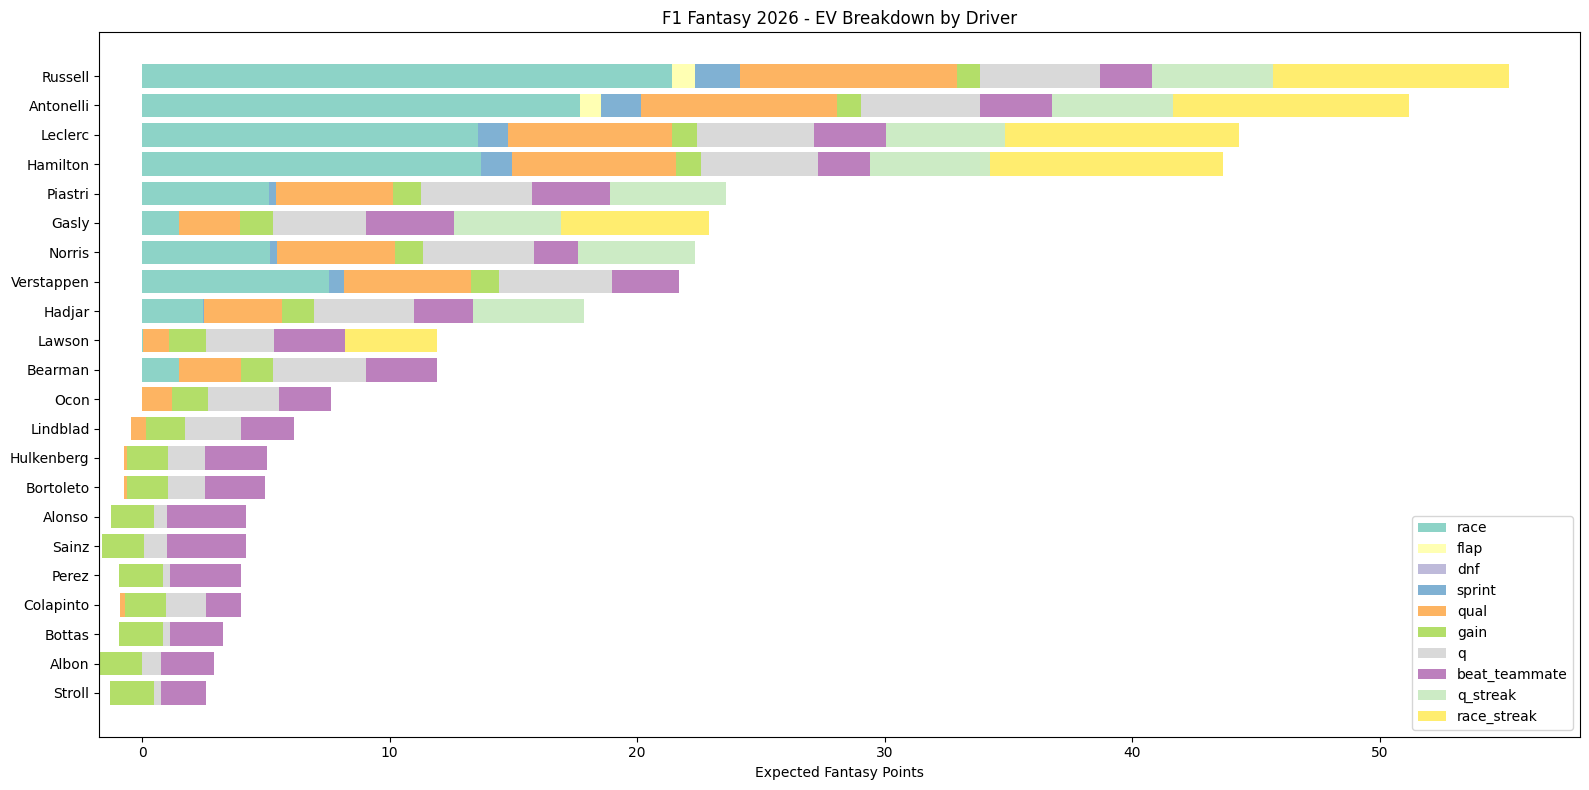

In [41]:
# Stacked bar chart of EV components per driver
fig, ax = plt.subplots(figsize=(16, 8))

ev_components = ['race', 'flap', 'dnf', 'sprint', 'qual', 'gain', 'q', 'beat_teammate', 'q_streak', 'race_streak']
available_components = [c for c in ev_components if c in ev_df.columns]

sorted_drivers = ev_df[available_components].sum(axis=1).sort_values(ascending=True).index

bottom = np.zeros(len(sorted_drivers))
colors = plt.cm.Set3(np.linspace(0, 1, len(available_components)))

for i, component in enumerate(available_components):
    values = ev_df.loc[sorted_drivers, component].values
    ax.barh(range(len(sorted_drivers)), values, left=bottom, label=component, color=colors[i])
    bottom += values

ax.set_yticks(range(len(sorted_drivers)))
ax.set_yticklabels(sorted_drivers)
ax.set_xlabel('Expected Fantasy Points')
ax.set_title('F1 Fantasy 2026 - EV Breakdown by Driver')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Notes on 2026 Regulation Reset

**Key uncertainties for 2026 predictions:**

1. **New regulation era**: The 2026 rules represent a fundamental reset. Historical performance from 2022-2025 is less predictive than usual. The odds markets (which incorporate pre-season testing and expert analysis) are our best signal.

2. **Power unit maturity**: New PU formula means manufacturers start from scratch. Teams with better electrical systems (MGU-K tripled to 350kW) will have structural advantages. Mercedes supplies 4 teams, Ferrari 3, RBPT 2, Honda 1, Audi 1.

3. **Active aero dynamics**: DRS is gone. Overtaking now depends on electrical energy management (Boost/Overtake modes). This could change the typical grid-to-race-position relationship.

4. **New teams**: Cadillac (11th team) and Audi (rebranded Sauber) add significant uncertainty. Both are expected to be at the back initially.

5. **Pre-season testing signals** (Bahrain 2026):
   - Ferrari (Leclerc): Fastest overall - 1:31.992
   - Mercedes (Antonelli): 2nd - 1:32.803
   - McLaren (Piastri/Norris): 3rd/4th - within 0.1s of each other
   - Red Bull (Verstappen): 5th - 1:33.109

**Model accuracy**: As with 2024, formal backtesting is not possible. The model's value lies in systematically converting market odds into optimal Fantasy team selections, not in predicting individual race outcomes.